<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Toxic_Text_Classification_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [82]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [84]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [85]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [86]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [87]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [88]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [89]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

In [90]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [91]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [92]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id  \
0  0000997932d777bf   
1  000103f0d9cfb60f   
2  000113f07ec002fd   
3  0001b41b1c6bb37e   
4  0001d958c54c6e35   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         comment_text  \
0                                                                                                                                                                                                                       

In [93]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [94]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [95]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [96]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id  \
0  00001cee341fdb12   
1  0000247867823ef7   
2  00013b17ad220c46   
3  00017563c3f7919a   
4  00017695ad8997eb   

                                                                                                                                                                                                                                                                                                                                                                      comment_text  \
0  Yo bitch Ja Rule is more succesful then you'll ever be whats up with you and hating you sad mofuckas...i should bitch slap ur pethedic white faces and get you to kiss my ass you guys sicken me. Ja rule is about pride in da music man. dont diss that shit on him. and nothin is wrong bein like tupac he was a brother too...fuckin white boys get things right next time.,   
1                                                                                                    

**Binary 'any_toxic' column **




In [97]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [98]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [99]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

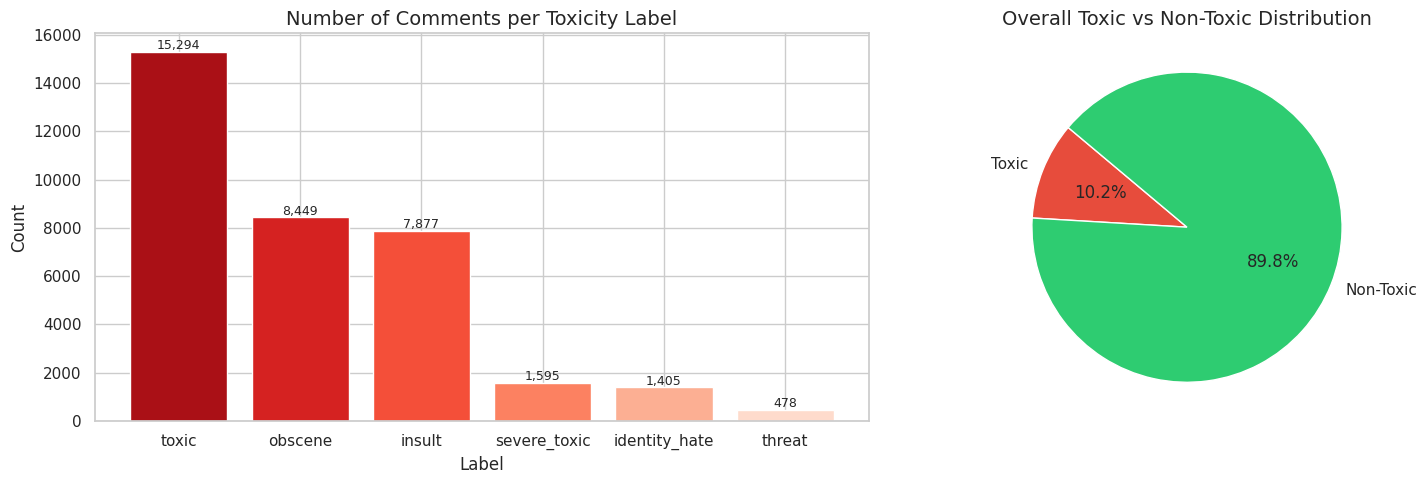

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [101]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

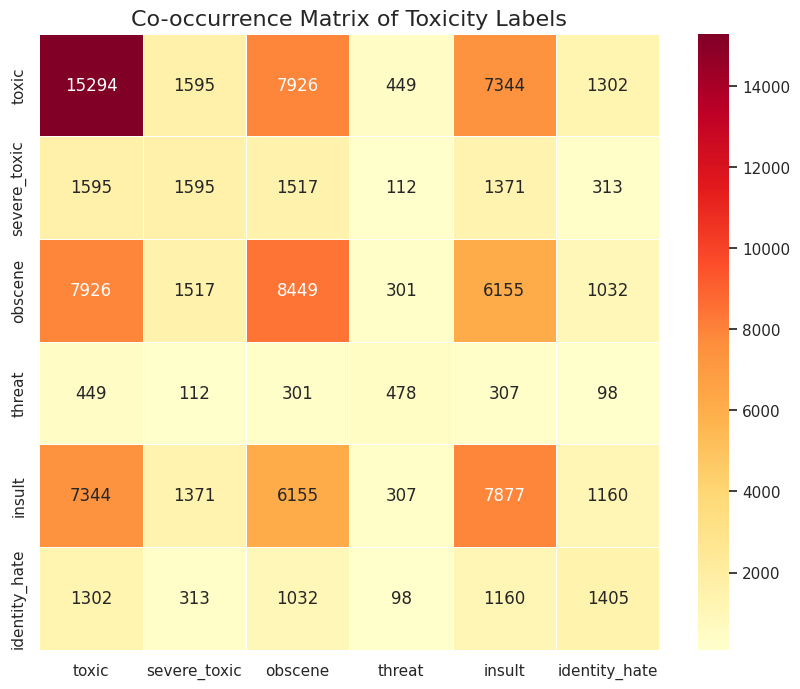

In [102]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

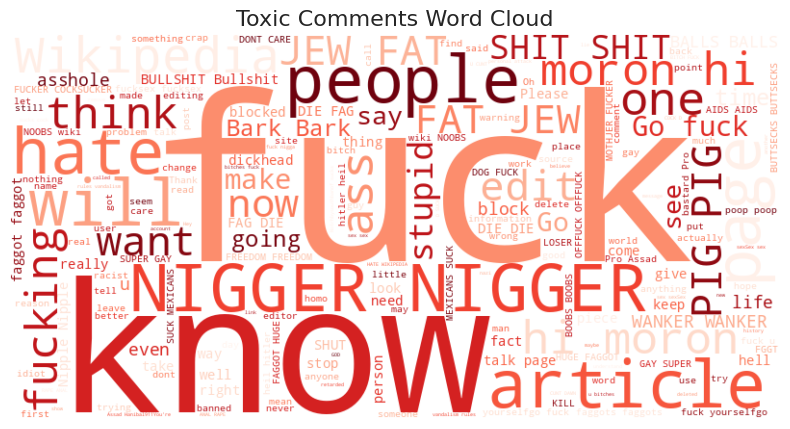

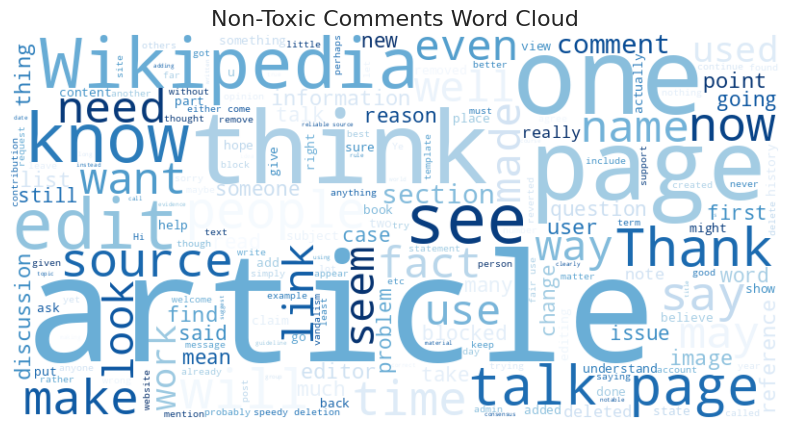

In [103]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

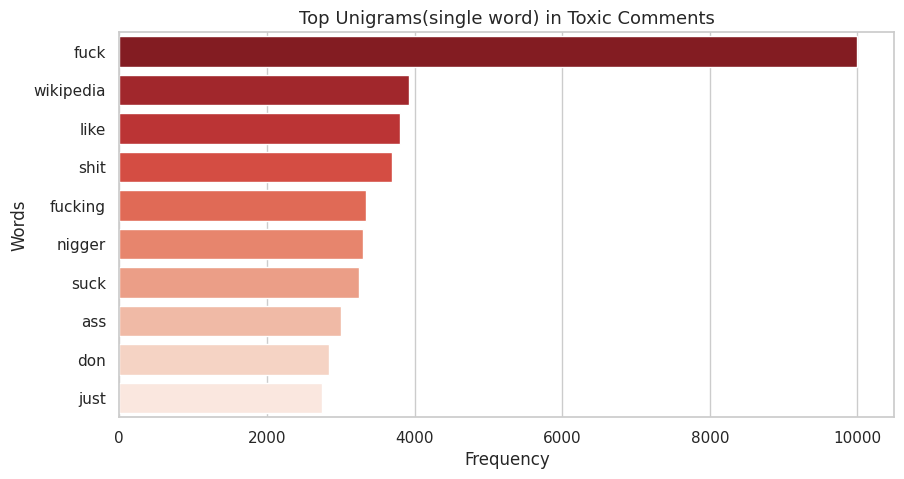

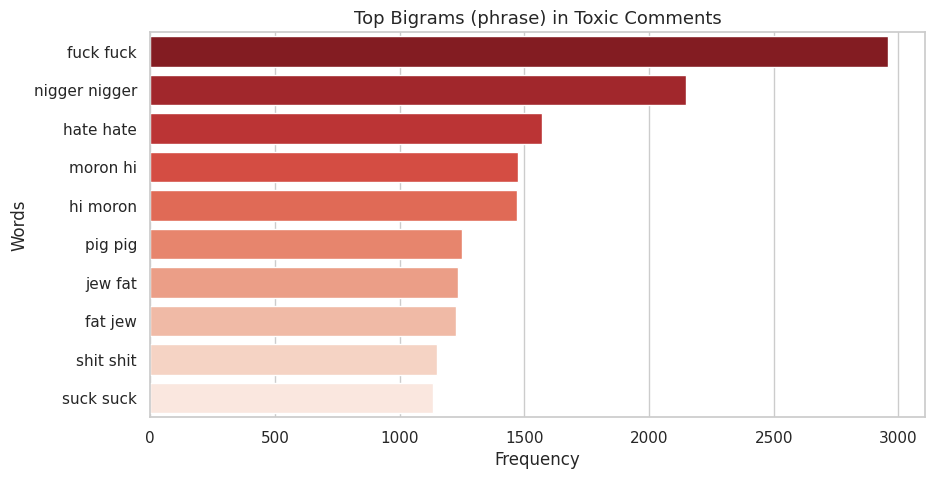

In [104]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [105]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
119105,"Geez, are you forgetful! We've already discussed why Marx was not an anarchist, i.e. he wanted to use a State to mold his 'socialist man.' Ergo, he is a statist - the opposite of an anarchist. I know a guy who says that, when he gets old and his teeth fall out, he'll quit eating meat. Would you call him a vegetarian?",0
131631,"Carioca RFA \n\nThanks for your support on my request for adminship.\n\nThe final outcome was (31/4/1), so I am now an administrator. If you have any comments or concerns on my actions as an administrator, please let me know. Thank you!",0
125326,"""\n\n Birthday \n\nNo worries, It's what I do ;)Enjoy ur day|talk|e """,0
111256,"Pseudoscience category? \n\nI'm assuming that this article is in the pseudoscience category because of its association with creationism. However, there are modern, scientifically-accepted variants of catastrophism that have nothing to do with creationism — and they're even mentioned in the article! I think the connection to pseudoscience needs to be clarified, or the article made more general and less creationism-specific and the category tag removed entirely.",0
83590,"(and if such phrase exists, it would be provided by search engine even if mentioned page is not available as a whole)",0
37546,", 9 October 2007 (UTC)\n\nP.s, the delta function I use in the example above as is the Kronecker delta, not the Dirac delta. The Kronecker delta is in , whereas the Dirac delta is not in L2[0,1].\n\nIncidentally, in response to the request for examples, L2(X) is not a RKHS for X any open subset of . On the other hand, Hardy spaces usually are RKHSs, using various variants of the Szego kernel.\n\nFor example , the Hilbert space of L2 functions on the circle is not a RKHS. On the other hand, , the space of L2 functions on the circle which are tangential limits of holomorphic functions on the disc, is. 14:18",0


**Basic Preprocessing**



1.   Lower case




In [106]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [107]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [108]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [109]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [110]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [111]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [112]:
!pip install emoji

1. Emoji to text

In [113]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [114]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [115]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [116]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [117]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [118]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [119]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [120]:
# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

Stopwords

In [121]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [122]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [123]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [124]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [125]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [126]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
80988,"""\n\nI have struck out my comment on the WP:RfC page, as you are quite correct in saying that I have no evidence for my """"suspicion"""", although I don't agree with your comment that you had """"already explained that you have been browsing WP for some time"""" - I can't see where you explained this previously. (talk) """
141463,please do not reinsert
44537,"""\n\nwell its not """"Vanderlism"""" as you state it. You still should allow the other part of my edit that you keep reverting because you hate the genre so much. 75.139.103.133 """
10601,"""\nFor the record, here is the news blurb that made en.wiki main page news: """"Amid an outbreak of tornadoes and derechos in central and eastern North America, a tornado hits a Boy Scout camp in Iowa, killing four.""""... — • Talk • """
149256,"cajuns, acadians\nCajuns, acadians, louisianans, they're so many different names for different americans of french descent because their culture is so rich and somewhat so different but so close at the same time. I'm an acadian but more importantly I'm a french american so I really don't see why there should be a difference. \n\nIf you say there should be two different list, it doesn't make sense. The people on the french-american list should be in one of wiki-invented list of cajuns or acadians. I understand there are some more recent french-americans who are only 1 or 2 generations-old americans but this distinction isn't made for italian-americans, german-americans. I'm surprised to see Albert Einstein a fairly recent immigrant in American history next to Katherine Heigl, a 10 to 12 generations american. \\\n\nThis is all race-based, biased because french-bashing don't stop at the bush government level."


Applying Basic Preprocessing

In [127]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
680,procedure do i ask you for the award michelle obama already has a million views this year and anthony davis basketball had a million in t c wpfour wpchicago wpwaward
29736,stop being a pussbot stop being a pussbot you are extremely biased wikipedia cannto tolerate users like you stop being a shudslavpus
109197,for how long exactly
66650,you changed the quote guards at parchman simply noted that the inmates proved more docile if they could get away to the red house with their women now and then to guards at parchman simply noted that the inmates proved more docile if they could get away to the tonk house with their women now and then
1285,fixed thanks for catching that


Comparison Of Raw and Basic Clean by Basic Preprocessing

In [128]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
108725,"July 2009 \n\nThe recent edit you made to soju constitutes vandalism, and has been reverted manually. Please do not continue to vandalize pages; use the sandbox for testing. Thanks.",july the recent edit you made to soju constitutes vandalism and has been reverted manually please do not continue to vandalize pages use the sandbox for testing thanks
102598,"""\n OK. Then don't )Although I resent your suggestion that I removed your comment to """"shield [...] the complete discussion,"""" especially since I just explained why I deleted it and the reason was completely different. I also agree with Kingpin, and think it somewhat inappropriate that you would be prepared to unblock an editor in exchange for concessions over a completely different issue to the one for which they were blocked. ╟─Tag►senator─╢ """,ok then dont although i resent your suggestion that i removed your comment to shield the complete discussion especially since i just explained why i deleted it and the reason was completely different i also agree with kingpin and think it somewhat inappropriate that you would be prepared to unblock an editor in exchange for concessions over a completely different issue to the one for which they were blocked tagsenator
149377,"An editor should be careful and specific about which edits are thought to be not NPOV before reverting another editor's hard work wholesale. For example, what is not NPOV about stating that Candace was killed at a home in Evergreen and not in Golden? Because it happens to be the geographical location of a lot of leading attachment therapists?\n\nThe therapists (plural) were not clearly unlicensed, as a reliable source has stated otherwise. It is POV to insist upon mistaken and misleading information be included, especially when the inclusion serves no good purpose.\n\nIt is a settled question that a reliable source about a topic can be listed in a reading section. Besides, I didn't list it in the first place.\n\nThe reversion is to a version which is, in my opinion, hopelessly inaccurate, biased and POV. Reversions to that version should stop.",an editor should be careful and specific about which edits are thought to be not npov before reverting another editors hard work wholesale for example what is not npov about stating that candace was killed at a home in evergreen and not in golden because it happens to be the geographical location of a lot of leading attachment therapists the therapists plural were not clearly unlicensed as a reliable source has stated otherwise it is pov to insist upon mistaken and misleading information be included especially when the inclusion serves no good purpose it is a settled question that a reliable source about a topic can be listed in a reading section besides i didnt list it in the first place the reversion is to a version which is in my opinion hopelessly inaccurate biased and pov reversions to that version should stop
11262,(Note: I have posted a message on WP:AN regarding the above unexpected turn/tone in the discussion.) (interact),note i have posted a message on wpan regarding the above unexpected turntone in the discussion interact
32217,Kurt Wallander. 194.81.33.9,kurt wallander


Applying Advanced Preprocessing

In [129]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [130]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
141488,complaint edits user talkedjohnston please see user talkedjohnstonusermehmeetts massive sock puppetry ip editor complained sock
55009,would consider entire wikiproject special case dec utc
45831,please vandalize page edit computer worm continue blocked editing scent
20373,taiwan japan section sinosing tie say relation improved lee august visit taiwan support japan permanent seat unsc huge problem bilateral relationship written press officer cheer k
79210,do vandal do vandal could please clear autoblocks


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [131]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
18186,poster \n\nIts official first look poster. It will be temporararily up on the page till Diwali when the theatrical poster comes out. Thanks.,poster official first look poster temporararily page till diwali theatrical poster come thanks
155888,"Cheesy Bread\nEven though Cheesy Bread may be good, the Batman & Robin article is not the place for the discussion of your favorite foods. Thanks and have a wonderful day.",cheesy bread even though cheesy bread may good batman robin article place discussion favorite food thanks wonderful day
52548,"""\n\nDYK for Church of La Soledad, Mexico City\n The DYK project (nominate) \n\nDYK for Centro Urbano Benito Juárez\n — • Talk • \n\nDYK for Colonia Buenos Aires\n The DYK project (nominate) \n\nDYK for Tlayacapan\n '''''' \n\n010 (UTC)""",dyk church la soledad mexico city dyk project nominate dyk centro urbano benito jurez talk dyk colonia buenos aire dyk project nominate dyk tlayacapan utc
13158,Archived copy (talk • contributions • email),archived copy talk contribution email
50805,"""\n\nLast Words\nThe plot summary mentions that """"We've won"""" are Cameron's last words. Did they mean the last words of the film, or did I miss something? Either way, should be edited for clarity.76.10.75.168 """,last word plot summary mention weve camerons last word mean last word film miss something either way edited clarity


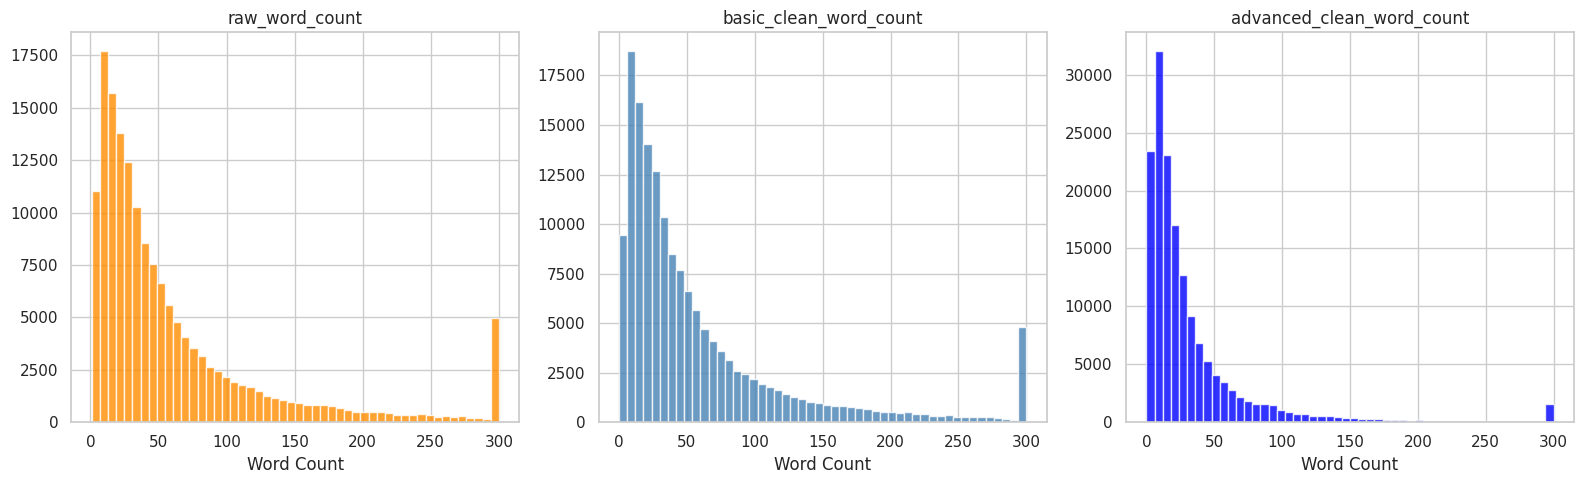

In [132]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [133]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [134]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [135]:
for i in range(2):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [137]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [138]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [139]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [140]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [141]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [142]:
Vocab_size =30000
max_len= 200

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts) # Corrected method name to texts_to_sequences
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [143]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 200)
LSTM shape val (15957, 200)
LSTM shape test (15958, 200)


3. BERT Tokenizer (for BERT) \
raw dataset

In [144]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [145]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

# Evaluation toolkit
for comparing easily

In [146]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [147]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [148]:
def plot_confusion(model_name,y_true, y_pred, labels, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), labels):
       cm = confusion_matrix(y_true[:, labels.index(col)],
                              y_pred[:, labels.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [149]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

In [150]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Train time: 21.5s


In [161]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [basic_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_raw.transform(sample_clean)

probs = lr_raw.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 95.61%
obscene: 99.98%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.86%
severe_toxic: 82.23%
obscene: 95.67%

Comment: Amazing work
Prediction: Non-toxic


Evaluate the model for raw data

In [151]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9207
  precision: 0.8385
  recall   : 0.3947
  f1 Macro : 0.5112
  train time: 21.5s


{'accuracy': 0.9207,
 'precision': 0.8385,
 'recall': 0.3947,
 'f1 (macro)': 0.5112,
 'train time (s)': 21.5,
 'infer time (s)': 0.1}

Confusion plot for the model for raw data

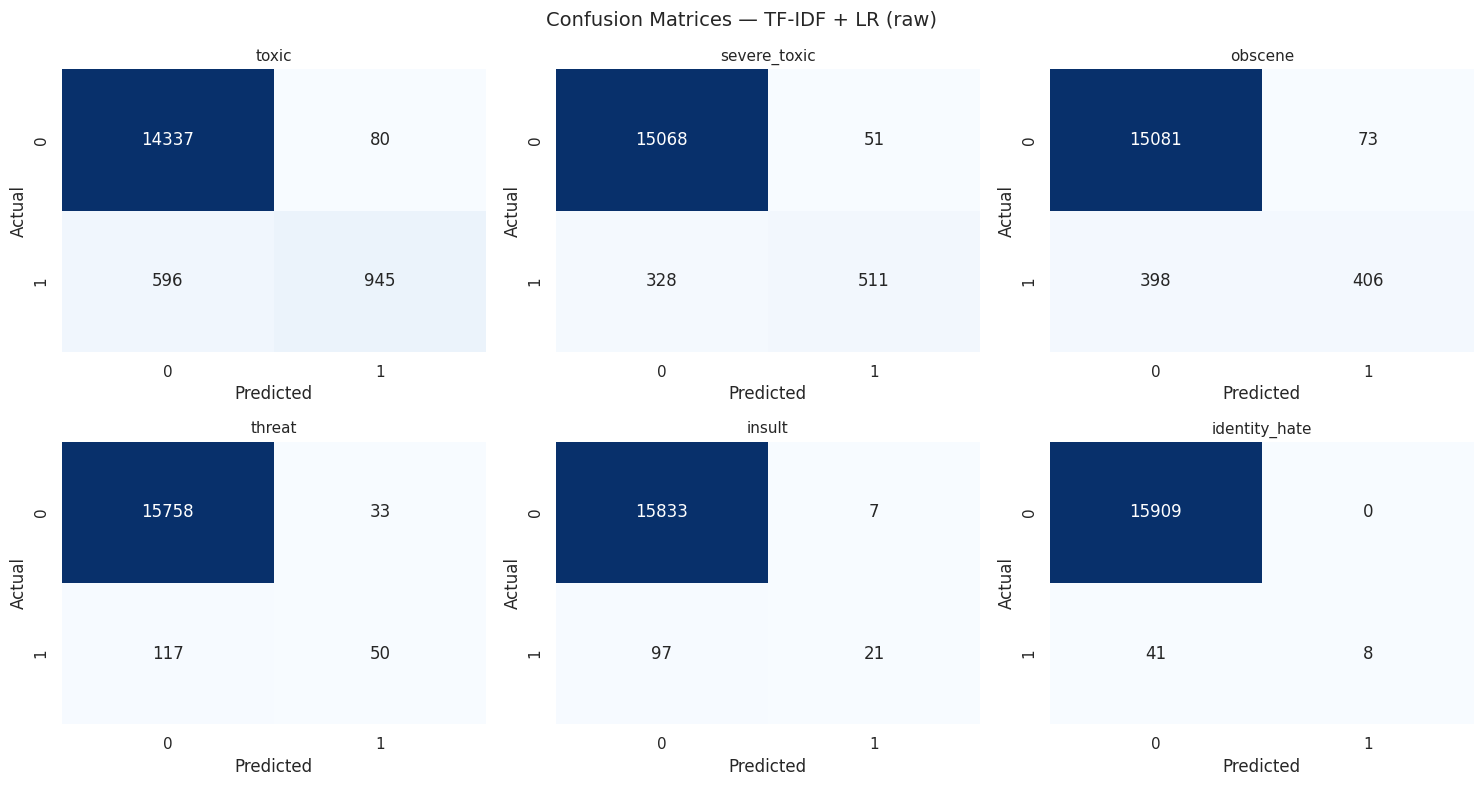

In [152]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

In [153]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 12.0s


In [154]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9180
  precision: 0.7550
  recall   : 0.3838
  f1 Macro : 0.4838
  train time: 12.0s


{'accuracy': 0.918,
 'precision': 0.755,
 'recall': 0.3838,
 'f1 (macro)': 0.4838,
 'train time (s)': 12.0,
 'infer time (s)': 0.1}

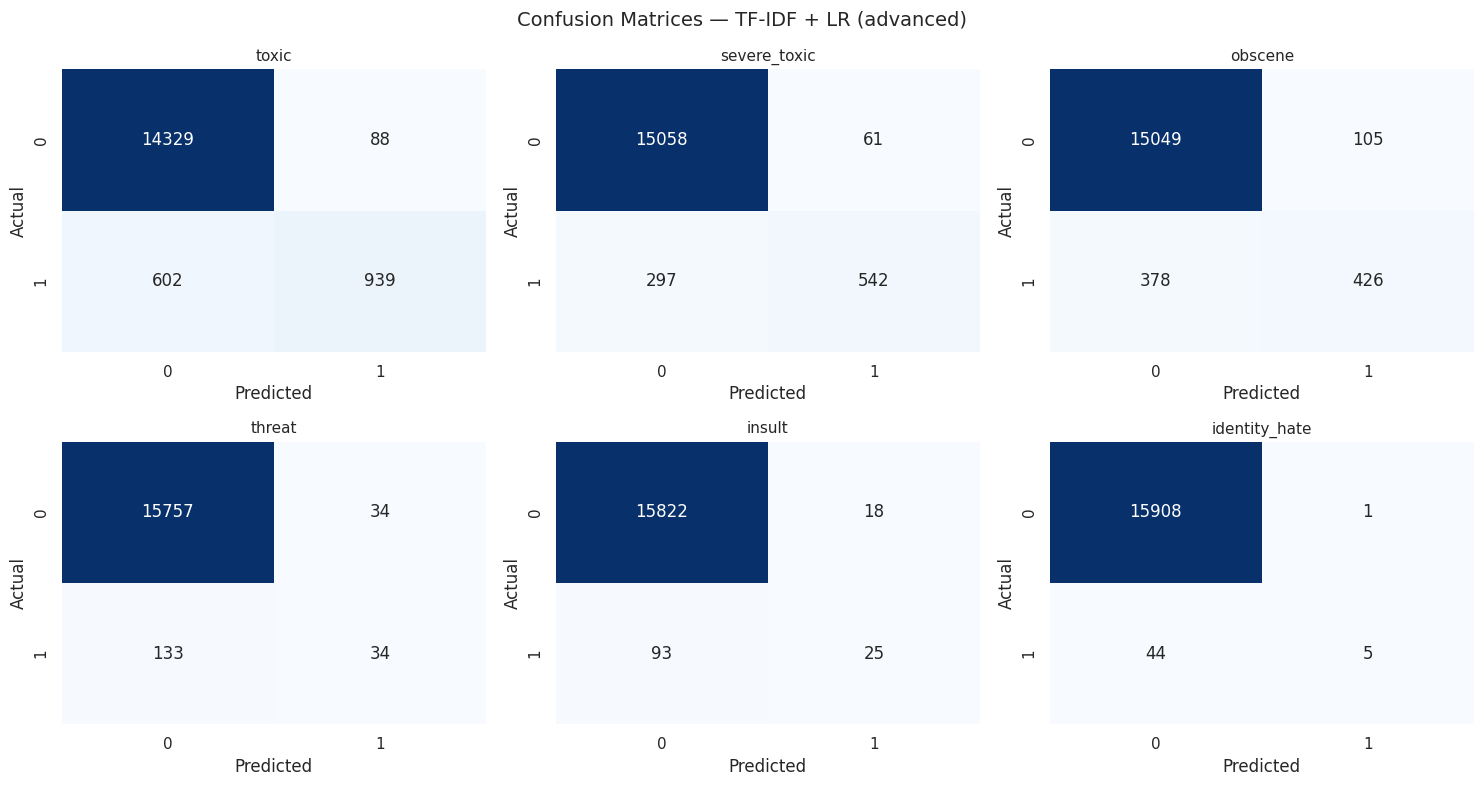

In [155]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.

In [160]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [advanced_preprocess(t) for t in sample_comments]
sample_tfidf = tfidf_clean.transform(sample_clean)

probs = lr_clean.predict_proba(sample_tfidf)

threshold = 0.5

for text, prob in zip(sample_comments, probs):

    print("\nComment:", text)

    toxic_found = False

    for label, p in zip(label_cols, prob):

        if p > threshold:
            toxic_found = True
            print(f"{label}: {p:.2%}")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: 100.00%
severe_toxic: 98.79%
obscene: 100.00%

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: 99.94%
severe_toxic: 89.66%
obscene: 99.23%

Comment: Amazing work
Prediction: Non-toxic
